<a href="https://colab.research.google.com/github/kundankumar09-v/weekly_assignments_CEI/blob/main/week2_kundan_kumar_vennaboina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")

In [5]:
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [7]:
df.shape

(2640, 12)

In [8]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [9]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
print(df['Region'].value_counts())
print(df['Model'].value_counts())
print(df['Source_Type'].value_counts())

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64


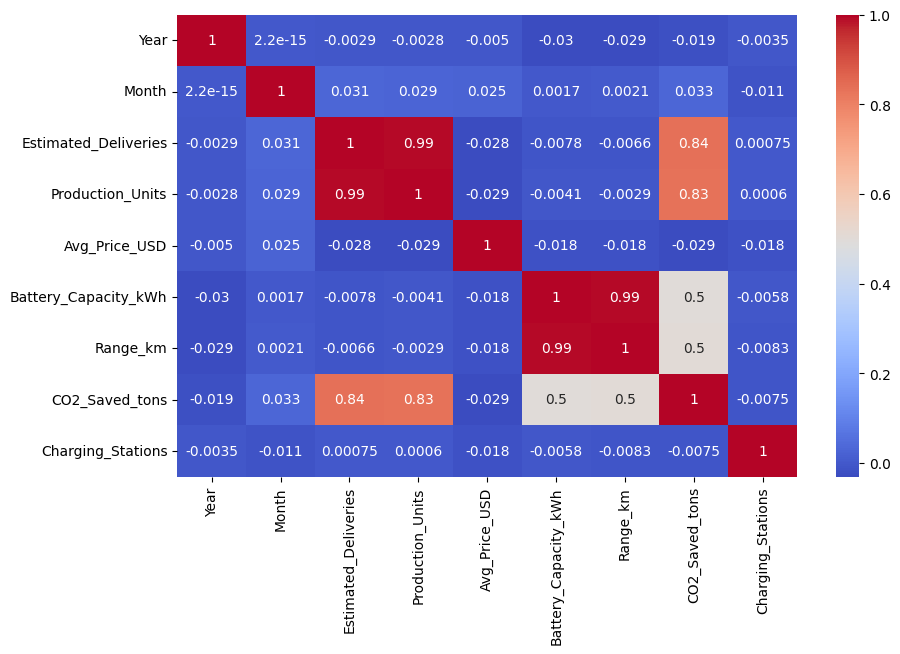

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.show()

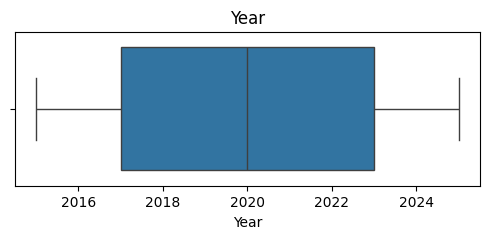

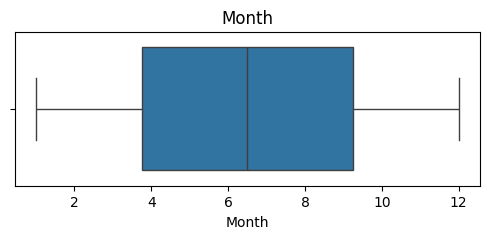

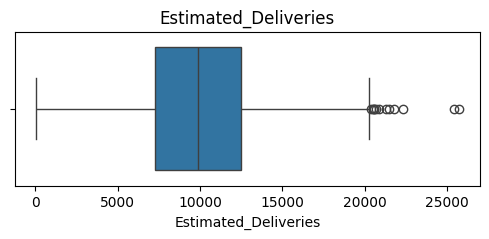

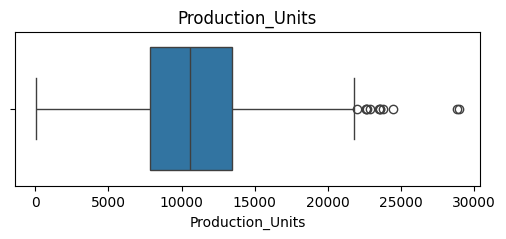

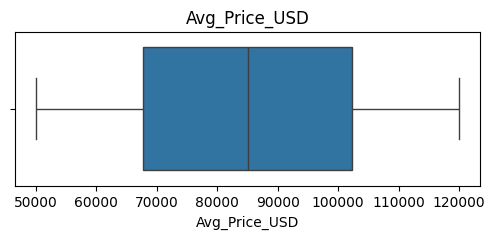

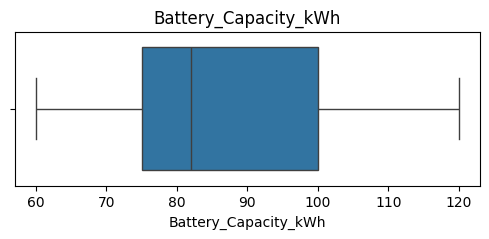

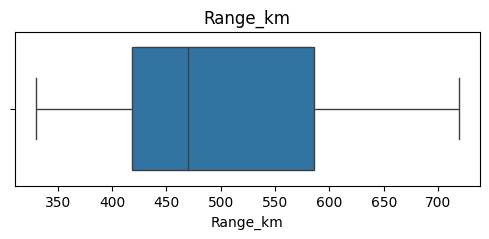

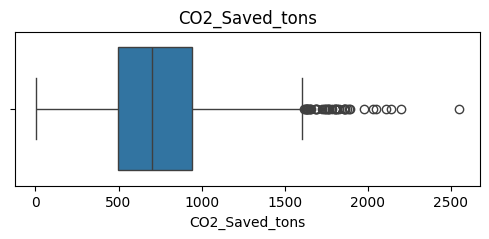

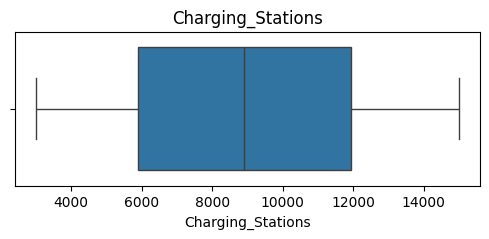

In [13]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [14]:
df['Delivery_Efficiency']=df['Estimated_Deliveries']/df['Production_Units']
df['Price_per_km']=df['Avg_Price_USD']/df['Range_km']
df['CO2_per_Delivery']=df['CO2_Saved_tons']/df['Estimated_Deliveries']

In [15]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in ['Region','Model','Source_Type']:
    df[col]=le.fit_transform(df[col])

In [16]:
df=df.drop('Range_km',axis=1)

In [17]:
df['Date']=pd.to_datetime(
    df['Year'].astype(str)+'-'+
    df['Month'].astype(str)+'-01'
)

In [18]:
y=df['Estimated_Deliveries']
X=df.drop(['Estimated_Deliveries','Date'],axis=1)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
lr=LinearRegression()
lr.fit(X_train,y_train)
lr_preds=lr.predict(X_test)

In [20]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
rf_preds=rf.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
def evaluate_model(y_true,y_pred,name):
    mae=mean_absolute_error(y_true,y_pred)
    rmse=np.sqrt(mean_squared_error(y_true,y_pred))
    r2=r2_score(y_true,y_pred)
    print(f"\n{name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}")
    return mae,rmse,r2

In [22]:
lr_mae,lr_rmse,lr_r2=evaluate_model(y_test,lr_preds,"Linear Regression")
rf_mae,rf_rmse,rf_r2=evaluate_model(y_test,rf_preds,"Random Forest")


Linear Regression
MAE: 108.89
RMSE: 153.33
R2 Score: 0.9984

Random Forest
MAE: 67.31
RMSE: 109.53
R2 Score: 0.9992


In [23]:
from xgboost import XGBRegressor
xgb=XGBRegressor(random_state=42)
xgb.fit(X_train,y_train)
xgb_preds=xgb.predict(X_test)
xgb_mae,xgb_rmse,xgb_r2=evaluate_model(y_test,xgb_preds,"XGBoost Regressor")


XGBoost Regressor
MAE: 72.62
RMSE: 103.51
R2 Score: 0.9993


In [24]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=3,
    verbose=1,
    n_jobs=-1
)
print("Starting GridSearchCV for XGBoost Regressor")
grid_search.fit(X_train, y_train)
print("GridSearchCV completed.")
best_params = grid_search.best_params_
best_score = -grid_search.best_score_
print(f"Best Hyperparameters: {best_params}")
print(f"Best Cross-validation MAE: {best_score:.2f}")
optimized_xgb_model = XGBRegressor(**best_params, random_state=42, n_jobs=-1)
optimized_xgb_model.fit(X_train, y_train)
optimized_xgb_preds = optimized_xgb_model.predict(X_test)
optimized_xgb_mae, optimized_xgb_rmse, optimized_xgb_r2 = evaluate_model(
    y_test, optimized_xgb_preds, "Optimized XGBoost Regressor"
)

Starting GridSearchCV for XGBoost Regressor
Fitting 3 folds for each of 243 candidates, totalling 729 fits
GridSearchCV completed.
Best Hyperparameters: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7}
Best Cross-validation MAE: 96.43

Optimized XGBoost Regressor
MAE: 79.70
RMSE: 113.38
R2 Score: 0.9991


                 Feature  Importance
4       Production_Units    0.989443
10   Delivery_Efficiency    0.008637
8            Source_Type    0.000532
0                   Year    0.000484
11          Price_per_km    0.000151
5          Avg_Price_USD    0.000137
3                  Model    0.000136
1                  Month    0.000119
7         CO2_Saved_tons    0.000099
12      CO2_per_Delivery    0.000079
9      Charging_Stations    0.000075
6   Battery_Capacity_kWh    0.000056
2                 Region    0.000052


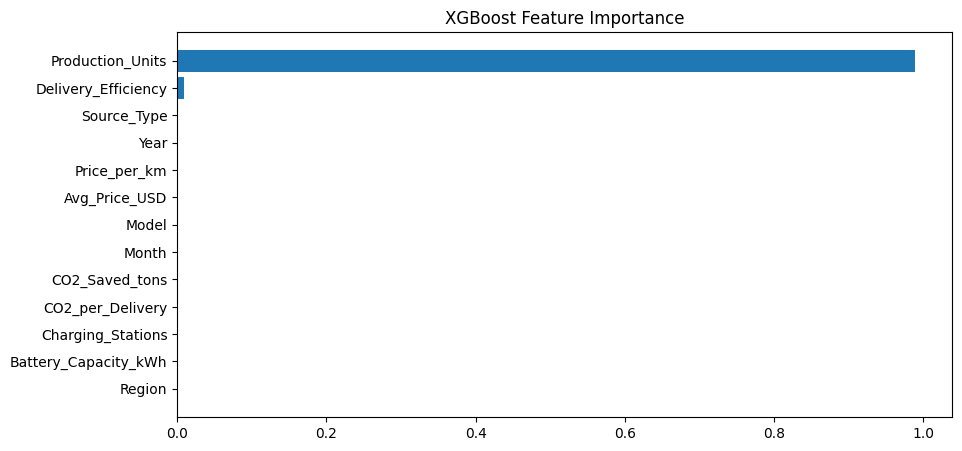

In [25]:
importance=pd.DataFrame({'Feature':X.columns,'Importance':xgb.feature_importances_})
importance=importance.sort_values('Importance',ascending=False)
print(importance)
plt.figure(figsize=(10,5))
plt.barh(importance['Feature'],importance['Importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.show()

In [26]:
X=df.drop(['Estimated_Deliveries','Date','Delivery_Efficiency','CO2_per_Delivery'],axis=1)
y=df['Estimated_Deliveries']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
lr=LinearRegression()
lr.fit(X_train,y_train)
lr_preds=lr.predict(X_test)
lr_mae,lr_rmse,lr_r2=evaluate_model(y_test,lr_preds,"Linear Regression")
rf=RandomForestRegressor(random_state=42)
rf.fit(X_train,y_train)
rf_preds=rf.predict(X_test)
rf_mae,rf_rmse,rf_r2=evaluate_model(y_test,rf_preds,"Random Forest")
xgb=XGBRegressor(random_state=42)
xgb.fit(X_train,y_train)
xgb_preds=xgb.predict(X_test)
xgb_mae,xgb_rmse,xgb_r2=evaluate_model(y_test,xgb_preds,"XGBoost Regressor")


Linear Regression
MAE: 310.66
RMSE: 384.14
R2 Score: 0.9901

Random Forest
MAE: 335.17
RMSE: 420.98
R2 Score: 0.9881

XGBoost Regressor
MAE: 274.47
RMSE: 356.11
R2 Score: 0.9915


                 Feature  Importance
4       Production_Units    0.980449
6   Battery_Capacity_kWh    0.005979
7         CO2_Saved_tons    0.004092
10          Price_per_km    0.001774
5          Avg_Price_USD    0.001448
0                   Year    0.001357
3                  Model    0.001321
9      Charging_Stations    0.001041
8            Source_Type    0.000945
1                  Month    0.000854
2                 Region    0.000740


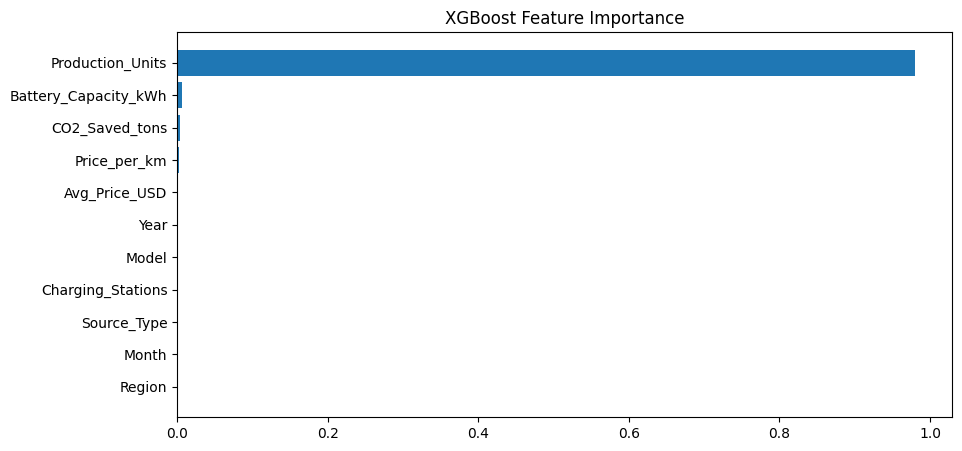

In [28]:
importance=pd.DataFrame({'Feature':X.columns,'Importance':xgb.feature_importances_})
importance=importance.sort_values('Importance',ascending=False)
print(importance)
plt.figure(figsize=(10,5))
plt.barh(importance['Feature'],importance['Importance'])
plt.gca().invert_yaxis()
plt.title('XGBoost Feature Importance')
plt.show()

In [29]:
results=pd.DataFrame({'Model':['Linear Regression','Random Forest','XGBoost'],'MAE':[lr_mae,rf_mae,xgb_mae],'RMSE':[lr_rmse,rf_rmse,xgb_rmse],'R2':[lr_r2,rf_r2,xgb_r2]
})
results=results.sort_values('R2',ascending=False)
print(results)

               Model         MAE        RMSE        R2
2            XGBoost  274.473694  356.109018  0.991493
0  Linear Regression  310.662063  384.135954  0.990101
1      Random Forest  335.174167  420.982790  0.988111


In [30]:
ts=df.groupby('Date')['Estimated_Deliveries'].sum().sort_index()
ts.head()

,Estimated_Deliveries
Date,
2015-01-01,183180
2015-02-01,165053
2015-03-01,184567
2015-04-01,225623
2015-05-01,184264


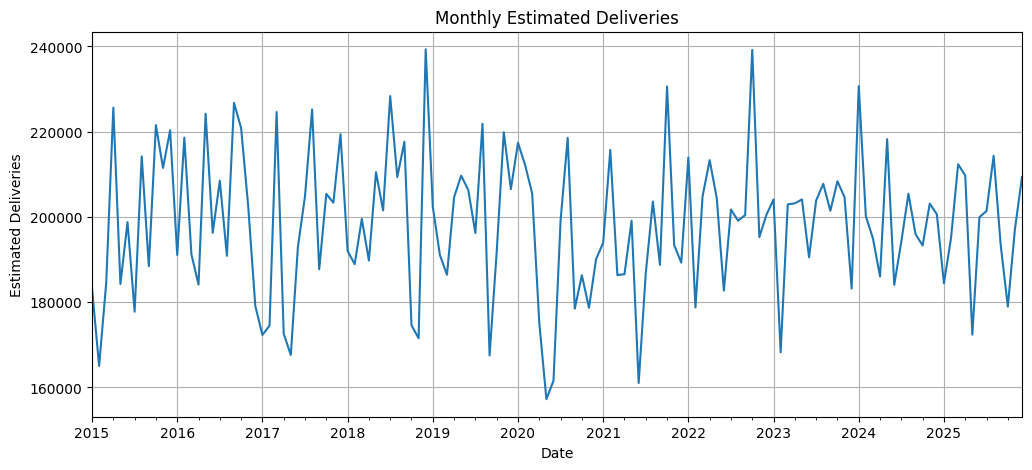

In [31]:
plt.figure(figsize=(12,5))
ts.plot()
plt.title('Monthly Estimated Deliveries')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.grid(True)
plt.show()

In [33]:
from statsmodels.tsa.stattools import adfuller
result=adfuller(ts)
print("ADF Statistic:",result[0])
print("p-value:",result[1])
for key,value in result[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: -8.880990349502861
p-value: 1.3181396968154354e-14
Critical Value (1%): -3.4816817173418295
Critical Value (5%): -2.8840418343195267
Critical Value (10%): -2.578770059171598


In [34]:
from statsmodels.tsa.arima.model import ARIMA
arima_model=ARIMA(ts,order=(1,0,1))
arima_result=arima_model.fit()
print(arima_result.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  132
Model:                   ARIMA(1, 0, 1)   Log Likelihood               -1469.876
Date:                  Sat, 06 Jun 2026   AIC                           2947.752
Time:                          12:33:37   BIC                           2959.283
Sample:                      01-01-2015   HQIC                          2952.437
                           - 12-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.984e+05    450.258    440.733      0.000    1.98e+05    1.99e+05
ar.L1          0.9286      0.036     25.772      0.000       0.858       0.999
ma.L1         -0.9993      0.138    

In [36]:
forecast=arima_result.forecast(steps=12)
print(forecast)

2026-01-01    198450.383859
2026-02-01    198449.892651
2026-03-01    198449.436501
2026-04-01    198449.012907
2026-05-01    198448.619546
2026-06-01    198448.254258
2026-07-01    198447.915042
2026-08-01    198447.600036
2026-09-01    198447.307512
2026-10-01    198447.035866
2026-11-01    198446.783607
2026-12-01    198446.549353
Freq: MS, Name: predicted_mean, dtype: float64


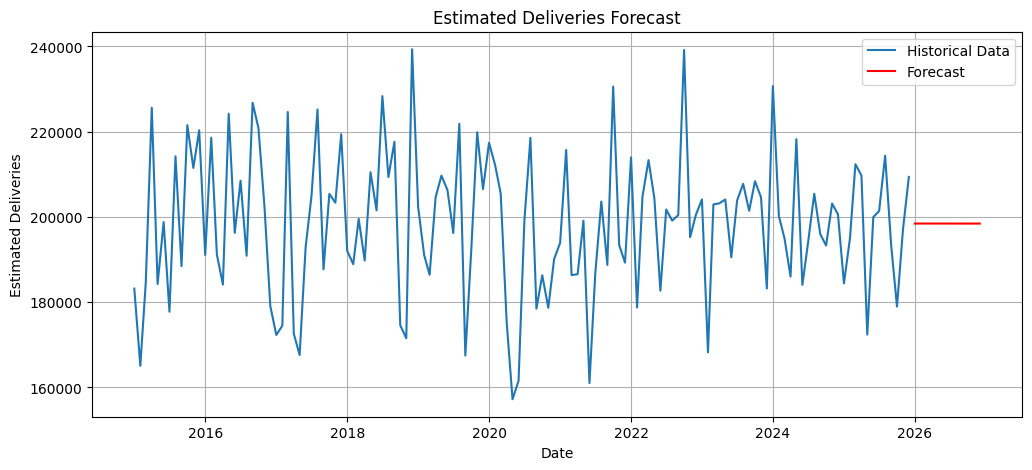

In [37]:
future_dates=pd.date_range(
    start=ts.index[-1]+pd.DateOffset(months=1),
    periods=12,
    freq='MS'
)
forecast_series=pd.Series(
    forecast.values,
    index=future_dates
)
plt.figure(figsize=(12,5))
plt.plot(ts,label='Historical Data')
plt.plot(forecast_series,label='Forecast',color='red')
plt.title('Estimated Deliveries Forecast')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.grid(True)
plt.show()

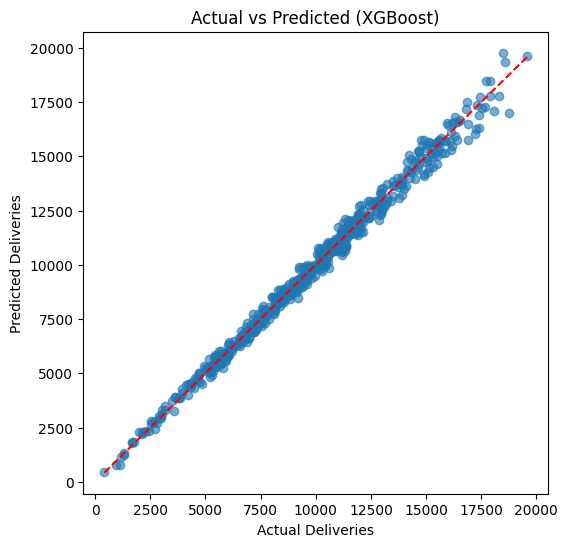

In [38]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,xgb_preds,alpha=0.6)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.xlabel('Actual Deliveries')
plt.ylabel('Predicted Deliveries')
plt.title('Actual vs Predicted (XGBoost)')
plt.show()